In [1]:
# Setup — build the jamie pipeline once and pre-compute a shared node
# layout. The cells below read from these module-level bindings:
#
#   c, rules, n_nodes      — the Circuit and its progress rules
#   op_names, op_types     — per-operator label + canonical type name
#   op_lo, op_hi           — per-operator node-index range (inclusive)
#   op_parents, n_ops      — operator-level edges
#   depths, x_of           — node-level layered layout
#   op_depth, op_x         — operator-level layered layout
#   PROGRESS_COLOR, COMPUTE_COLOR, OP_TYPE_COLOR — fill palettes

import matplotlib

# Labels in the plots below use unicode glyphs (→, ↔, ↻, ω, ⊤, ⊥, —) that
# the OS-default Helvetica on macOS doesn't ship. DejaVu Sans (bundled
# with matplotlib) has all of them. Belt: configure matplotlib's rcParams.
matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["font.sans-serif"] = ["DejaVu Sans", "Liberation Sans", "Arial"]

import pandas as pd
from plotnine import (
    aes, arrow, element_blank, facet_wrap, geom_label, geom_rect, geom_segment,
    geom_text, ggplot, labs, scale_fill_manual, theme, theme_bw as _theme_bw,
)


def theme_bw(base_size: int = 11, base_family: str | None = "DejaVu Sans"):
    """Suspenders: plotnine's themes can override matplotlib's rcParams.
    Default ``base_family`` to DejaVu Sans so every plot cell's
    ``theme_bw()`` call carries the font through, no matter what
    rcParams say."""
    return _theme_bw(base_size=base_size, base_family=base_family)


from pydbsp.circuit import Circuit
from pydbsp.indexed_relational_operators import (
    IndexedDeltaLiftedDeltaLiftedJoin, LiftGroupBy, LiftIndex,
)
from pydbsp.operator import (
    Differentiate, Input, Integrate, Lift1, LiftStreamIntroduction,
)
from pydbsp.progress import Time
from pydbsp.core import Antichain, dbsp_time
from pydbsp.indexed_zset import IndexedZSetAddition
from pydbsp.zset import ZSet, ZSetAddition

# ---- Build the jamie pipeline -----------------------------------------------
# Mirror of algebra.bench.bench_kafi_replay (Circuit wiring only).
# Each high-level operator is recorded with: label, canonical type name,
# and the contiguous range of node ids it materialised into.

Record = tuple[int, int, int, int]
AccountTotal = tuple[int, int]
eg_record = ZSetAddition[Record]()
eg_acc_total = ZSetAddition[AccountTotal]()
idx_by_acc = IndexedZSetAddition[int, AccountTotal](eg_acc_total, lambda kv: kv[0])

c = Circuit[Time]()
op_names: list[str] = []
op_types: list[str] = []
op_lo: list[int] = []
op_hi: list[int] = []
op_parents: list[tuple[int, ...]] = []

def _record(name: str, op_type: str, parents: tuple[int, ...]) -> int:
    """Tag every node added since the previous call as belonging to ``name``."""
    op_names.append(name)
    op_types.append(op_type)
    op_lo.append((op_hi[-1] + 1) if op_hi else 0)
    op_hi.append(len(c.progress_rules) - 1)
    op_parents.append(parents)
    return len(op_names) - 1

src = Input[ZSet[Record]](frontier=Antichain(dbsp_time(1))).connect(c, ())
o_src = _record("src", "Input", ())
src_2d = LiftStreamIntroduction[ZSet[Record]](group=eg_record).connect(c, (src,))
o_src_2d = _record("src_2d", "LiftStreamIntroduction", (o_src,))
cum_src = Integrate[ZSet[Record]](group=eg_record).connect(c, (src_2d,))
o_cum = _record("cum_src", "Integrate", (o_src_2d,))

indexed_to = LiftIndex[Record, int](indexer=lambda r: r[2]).connect(c, (cum_src,))
o_it = _record("indexed_to", "LiftIndex", (o_cum,))
credits = LiftGroupBy[Record, int, int](
    aggregate=lambda items: sum(r[3] * w for r, w in items),
).connect(c, (indexed_to,))
o_cr = _record("credits", "LiftGroupBy", (o_it,))

indexed_from = LiftIndex[Record, int](indexer=lambda r: r[1]).connect(c, (cum_src,))
o_if = _record("indexed_from", "LiftIndex", (o_cum,))
debits = LiftGroupBy[Record, int, int](
    aggregate=lambda items: sum(r[3] * w for r, w in items),
).connect(c, (indexed_from,))
o_db = _record("debits", "LiftGroupBy", (o_if,))

delta_credits = Differentiate[ZSet[AccountTotal]](group=eg_acc_total).connect(c, (credits,))
o_dc = _record("delta_credits", "Differentiate", (o_cr,))
delta_debits = Differentiate[ZSet[AccountTotal]](group=eg_acc_total).connect(c, (debits,))
o_dd = _record("delta_debits", "Differentiate", (o_db,))

indexed_dc = LiftIndex[AccountTotal, int](indexer=lambda kv: kv[0]).connect(c, (delta_credits,))
o_idc = _record("indexed_dc", "LiftIndex", (o_dc,))
indexed_dd = LiftIndex[AccountTotal, int](indexer=lambda kv: kv[0]).connect(c, (delta_debits,))
o_idd = _record("indexed_dd", "LiftIndex", (o_dd,))

balance_delta = IndexedDeltaLiftedDeltaLiftedJoin[
    int, AccountTotal, AccountTotal, AccountTotal,
](
    proj=lambda k, cd, dd: (k, cd[1] - dd[1]),
    group_a=idx_by_acc, group_b=idx_by_acc, out_group=eg_acc_total,
).connect(c, (indexed_dc, indexed_dd))
o_bd = _record("balance_delta", "IndexedDeltaLiftedDeltaLiftedJoin", (o_idc, o_idd))

balance = Integrate[ZSet[AccountTotal]](group=eg_acc_total).connect(c, (balance_delta,))
o_bal = _record("balance", "Integrate", (o_bd,))
indexed_balance = LiftIndex[AccountTotal, tuple[()]](
    indexer=lambda _kv: (),
).connect(c, (balance,))
o_ib = _record("indexed_balance", "LiftIndex", (o_bal,))
total_gb = LiftGroupBy[AccountTotal, tuple[()], int](
    aggregate=lambda items: sum(b[1] * w for b, w in items),
).connect(c, (indexed_balance,))
o_tgb = _record("total_gb", "LiftGroupBy", (o_ib,))
total = Lift1[ZSet[tuple[tuple[()], int]], int](
    f=lambda z: next((cnt for (_k, cnt), _w in z.inner.items()), 0),
).connect(c, (total_gb,))
o_tot = _record("total", "Lift1", (o_tgb,))

rules = c.progress_rules
n_nodes = len(rules)
n_ops = len(op_names)

# ---- Node-level layered layout ---------------------------------------------
# y = longest input → self path. x within each layer = barycenter of input
# x-positions (ties by node id) — keeps edge crossings low.

depths = [0] * n_nodes
for i, p in enumerate(rules):
    if p.inputs:
        depths[i] = 1 + max(depths[b] for b in p.inputs)

_node_layers: dict[int, list[int]] = {}
for i, d in enumerate(depths):
    _node_layers.setdefault(d, []).append(i)

x_of: dict[int, float] = {}
NODE_SPACING = 1.5
for d in sorted(_node_layers):
    layer = _node_layers[d]
    if d == 0:
        ordered = list(layer)
    else:
        def _bary(i: int) -> float:
            xs = [x_of[b] for b in rules[i].inputs if b in x_of]
            return sum(xs) / len(xs) if xs else 0.0
        ordered = sorted(layer, key=lambda i: (_bary(i), i))
    n = len(ordered)
    for k, i in enumerate(ordered):
        x_of[i] = (k - (n - 1) / 2) * NODE_SPACING

# ---- Operator-level layered layout -----------------------------------------

op_depth = [0] * n_ops
for i, parents in enumerate(op_parents):
    if parents:
        op_depth[i] = 1 + max(op_depth[p] for p in parents)

_op_layers: dict[int, list[int]] = {}
for i, d in enumerate(op_depth):
    _op_layers.setdefault(d, []).append(i)

op_x: dict[int, float] = {}
OP_SPACING = 4.0
for d in sorted(_op_layers):
    layer = _op_layers[d]
    if d == 0:
        ordered = list(layer)
    else:
        def _bary_op(i: int) -> float:
            xs = [op_x[p] for p in op_parents[i] if p in op_x]
            return sum(xs) / len(xs) if xs else 0.0
        ordered = sorted(layer, key=lambda i: (_bary_op(i), i))
    n = len(ordered)
    for k, i in enumerate(ordered):
        op_x[i] = (k - (n - 1) / 2) * OP_SPACING

# ---- Shape → colour palettes -----------------------------------------------

PROGRESS_COLOR = {
    "Input":            "#a8d8a8",
    "Identity":         "#cce5ff",
    "Meet":             "#5b9bd5",
    "AxisShift":        "#f4b860",
    "AxisIntroduction": "#c39bd3",
    "Feedback":         "#e57373",
}
COMPUTE_COLOR = {
    "Get":      "#a8d8a8",
    "Map":      "#cce5ff",
    "ZipWith":  "#5b9bd5",
    "Prev":     "#f4b860",
    "Constant": "#c39bd3",
    "Sum":      "#e57373",
}
OP_TYPE_COLOR = {
    "Input":                            "#a8d8a8",
    "LiftStreamIntroduction":           "#c39bd3",
    "Integrate":                        "#e57373",
    "Differentiate":                    "#f4b860",
    "LiftIndex":                        "#cce5ff",
    "LiftGroupBy":                      "#5b9bd5",
    "IndexedDeltaLiftedDeltaLiftedJoin": "#3d7da6",
    "Lift1":                            "#f4a6c4",
}

print(f"jamie pipeline: {n_ops} operators → {n_nodes} progress/compute nodes")

jamie pipeline: 16 operators → 36 progress/compute nodes


# Antichain exploration

A scratchpad for reviewing pydbsp v2's antichain machinery (`algebra/progress.py`).

The example throughout is the **jamie SQL aggregate pipeline** (mirrored in `algebra.bench.bench_kafi_replay`):

```
total   = SUM(balance)
balance = credits − debits         (per account)
credits = SUM(amount) over txns grouped by to_account
debits  = SUM(amount) over txns grouped by from_account
```

The setup cell above builds it once. The three visualisations below show the same pipeline at increasing levels of detail:

1. **Operator DAG** — the 16 high-level operators (`Input`, `LiftStreamIntroduction`, `Integrate`, `LiftIndex`, `LiftGroupBy`, `Differentiate`, `IndexedDeltaLiftedDeltaLiftedJoin`, `Lift1`) connected by feeds-into edges.
2. **Compute DAG** — all 36 nodes, each tagged with its `algebra.compute` rule (`Get` / `Map` / `ZipWith` / `Prev` / `Constant` / `Sum`).
3. **Progress DAG** — same 36 nodes, tagged with their `algebra.progress` shape (`Input` / `Identity` / `Meet` / `AxisShift` / `AxisIntroduction` / `Feedback`).

Dashed outlines on the Compute and Progress views group the nodes by which high-level operator they belong to. `↻` flags self-edges on `Feedback` / `Sum` nodes (not drawn — the `inputs` / `reads` relation only lists external edges).

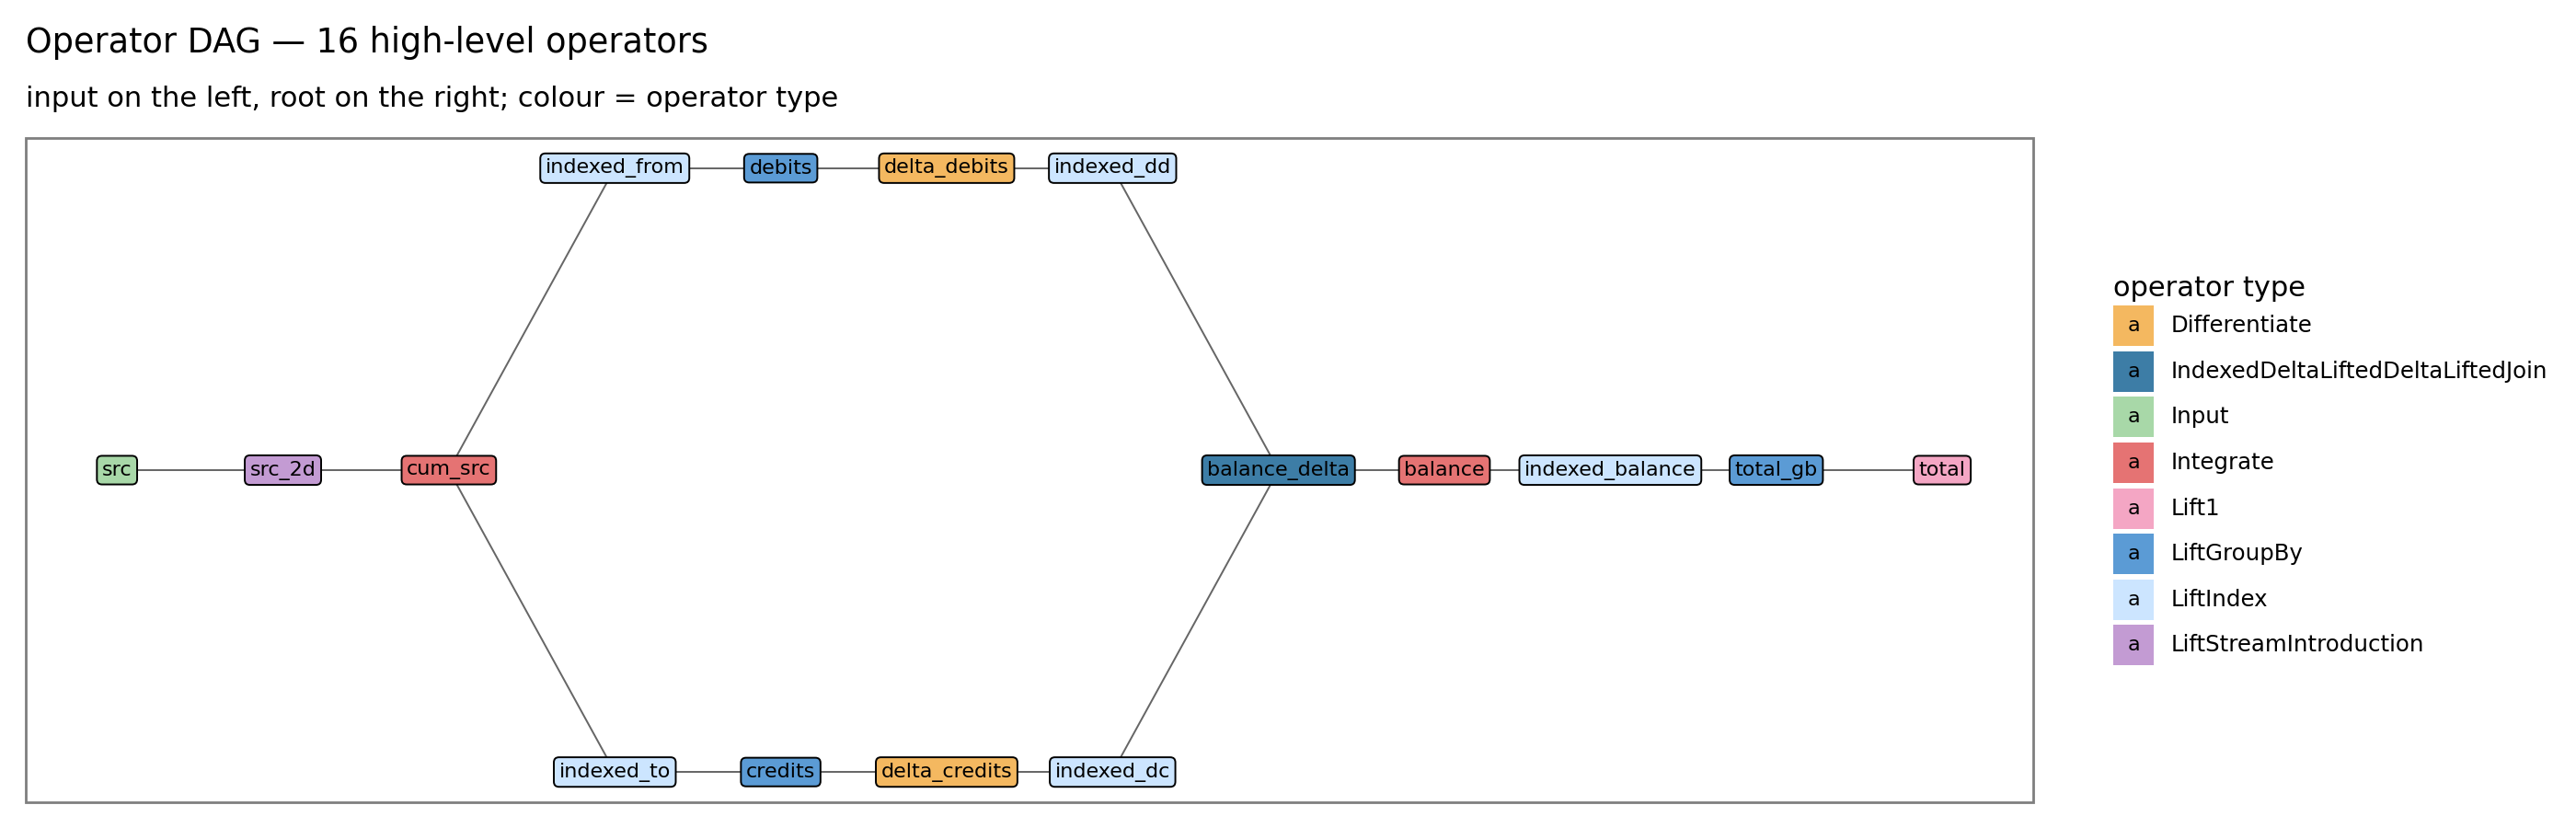

In [2]:
# Operator DAG — 16 operators rendered left-to-right (input on the left,
# root on the right). The jamie pipeline is long-and-thin (12 depth
# layers, max width 2), so the horizontal layout fits more comfortably
# than the bottom-up convention used by the node-level DAGs below. Fill
# colour encodes the operator's type; the legend lists the eight types
# in play.

DEPTH_SPACING = 2.6

op_nodes_df = pd.DataFrame([
    {
        "x": op_depth[i] * DEPTH_SPACING,
        "y": op_x[i],
        "label": op_names[i],
        "op_type": op_types[i],
    }
    for i in range(n_ops)
])
op_edges_df = pd.DataFrame([
    {
        "x": op_depth[p] * DEPTH_SPACING, "y": op_x[p],
        "xend": op_depth[i] * DEPTH_SPACING, "yend": op_x[i],
    }
    for i, parents in enumerate(op_parents) for p in parents
])

(
    ggplot()
    + geom_segment(
        data=op_edges_df,
        mapping=aes(x="x", y="y", xend="xend", yend="yend"),
        arrow=arrow(angle=18, length=0.07),
        size=0.4, color="#666666",
    )
    + geom_label(
        data=op_nodes_df,
        mapping=aes(x="x", y="y", label="label", fill="op_type"),
        size=8,
    )
    + scale_fill_manual(values=OP_TYPE_COLOR)
    + theme_bw()
    + theme(
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
        axis_title=element_blank(),
        figure_size=(14, 4.5),
    )
    + labs(
        title=f"Operator DAG — {n_ops} high-level operators",
        subtitle="input on the left, root on the right; colour = operator type",
        fill="operator type",
    )
)

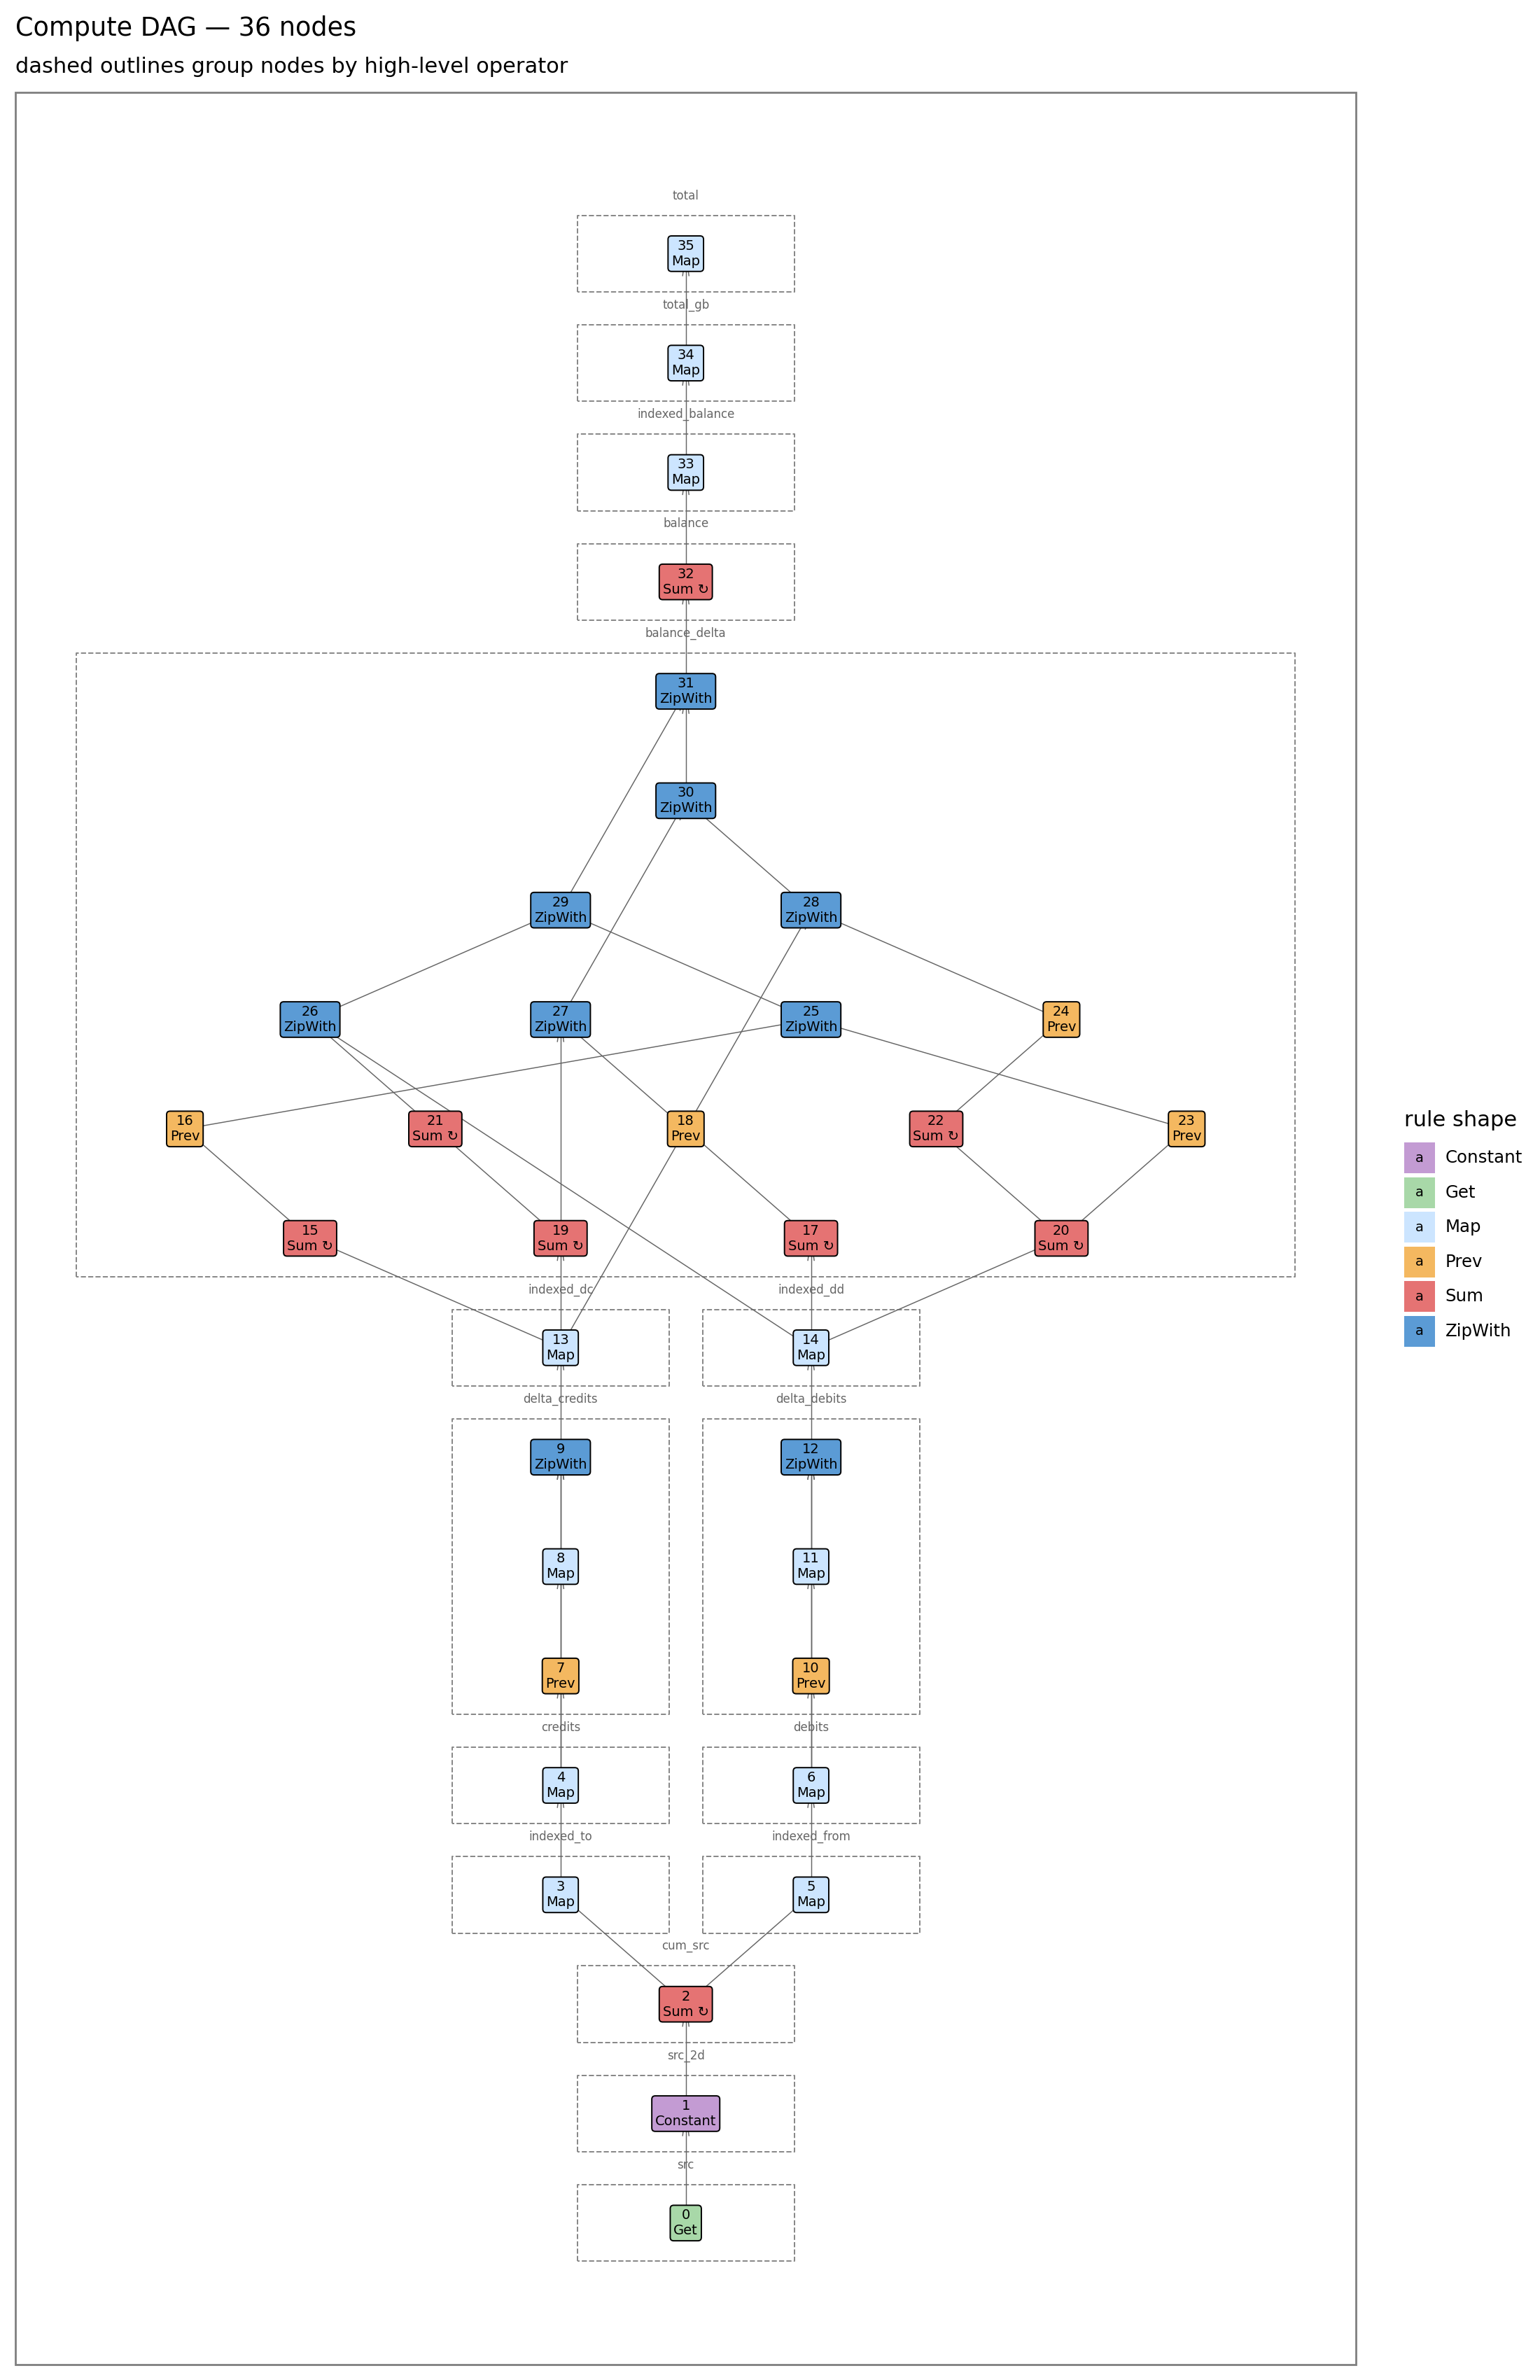

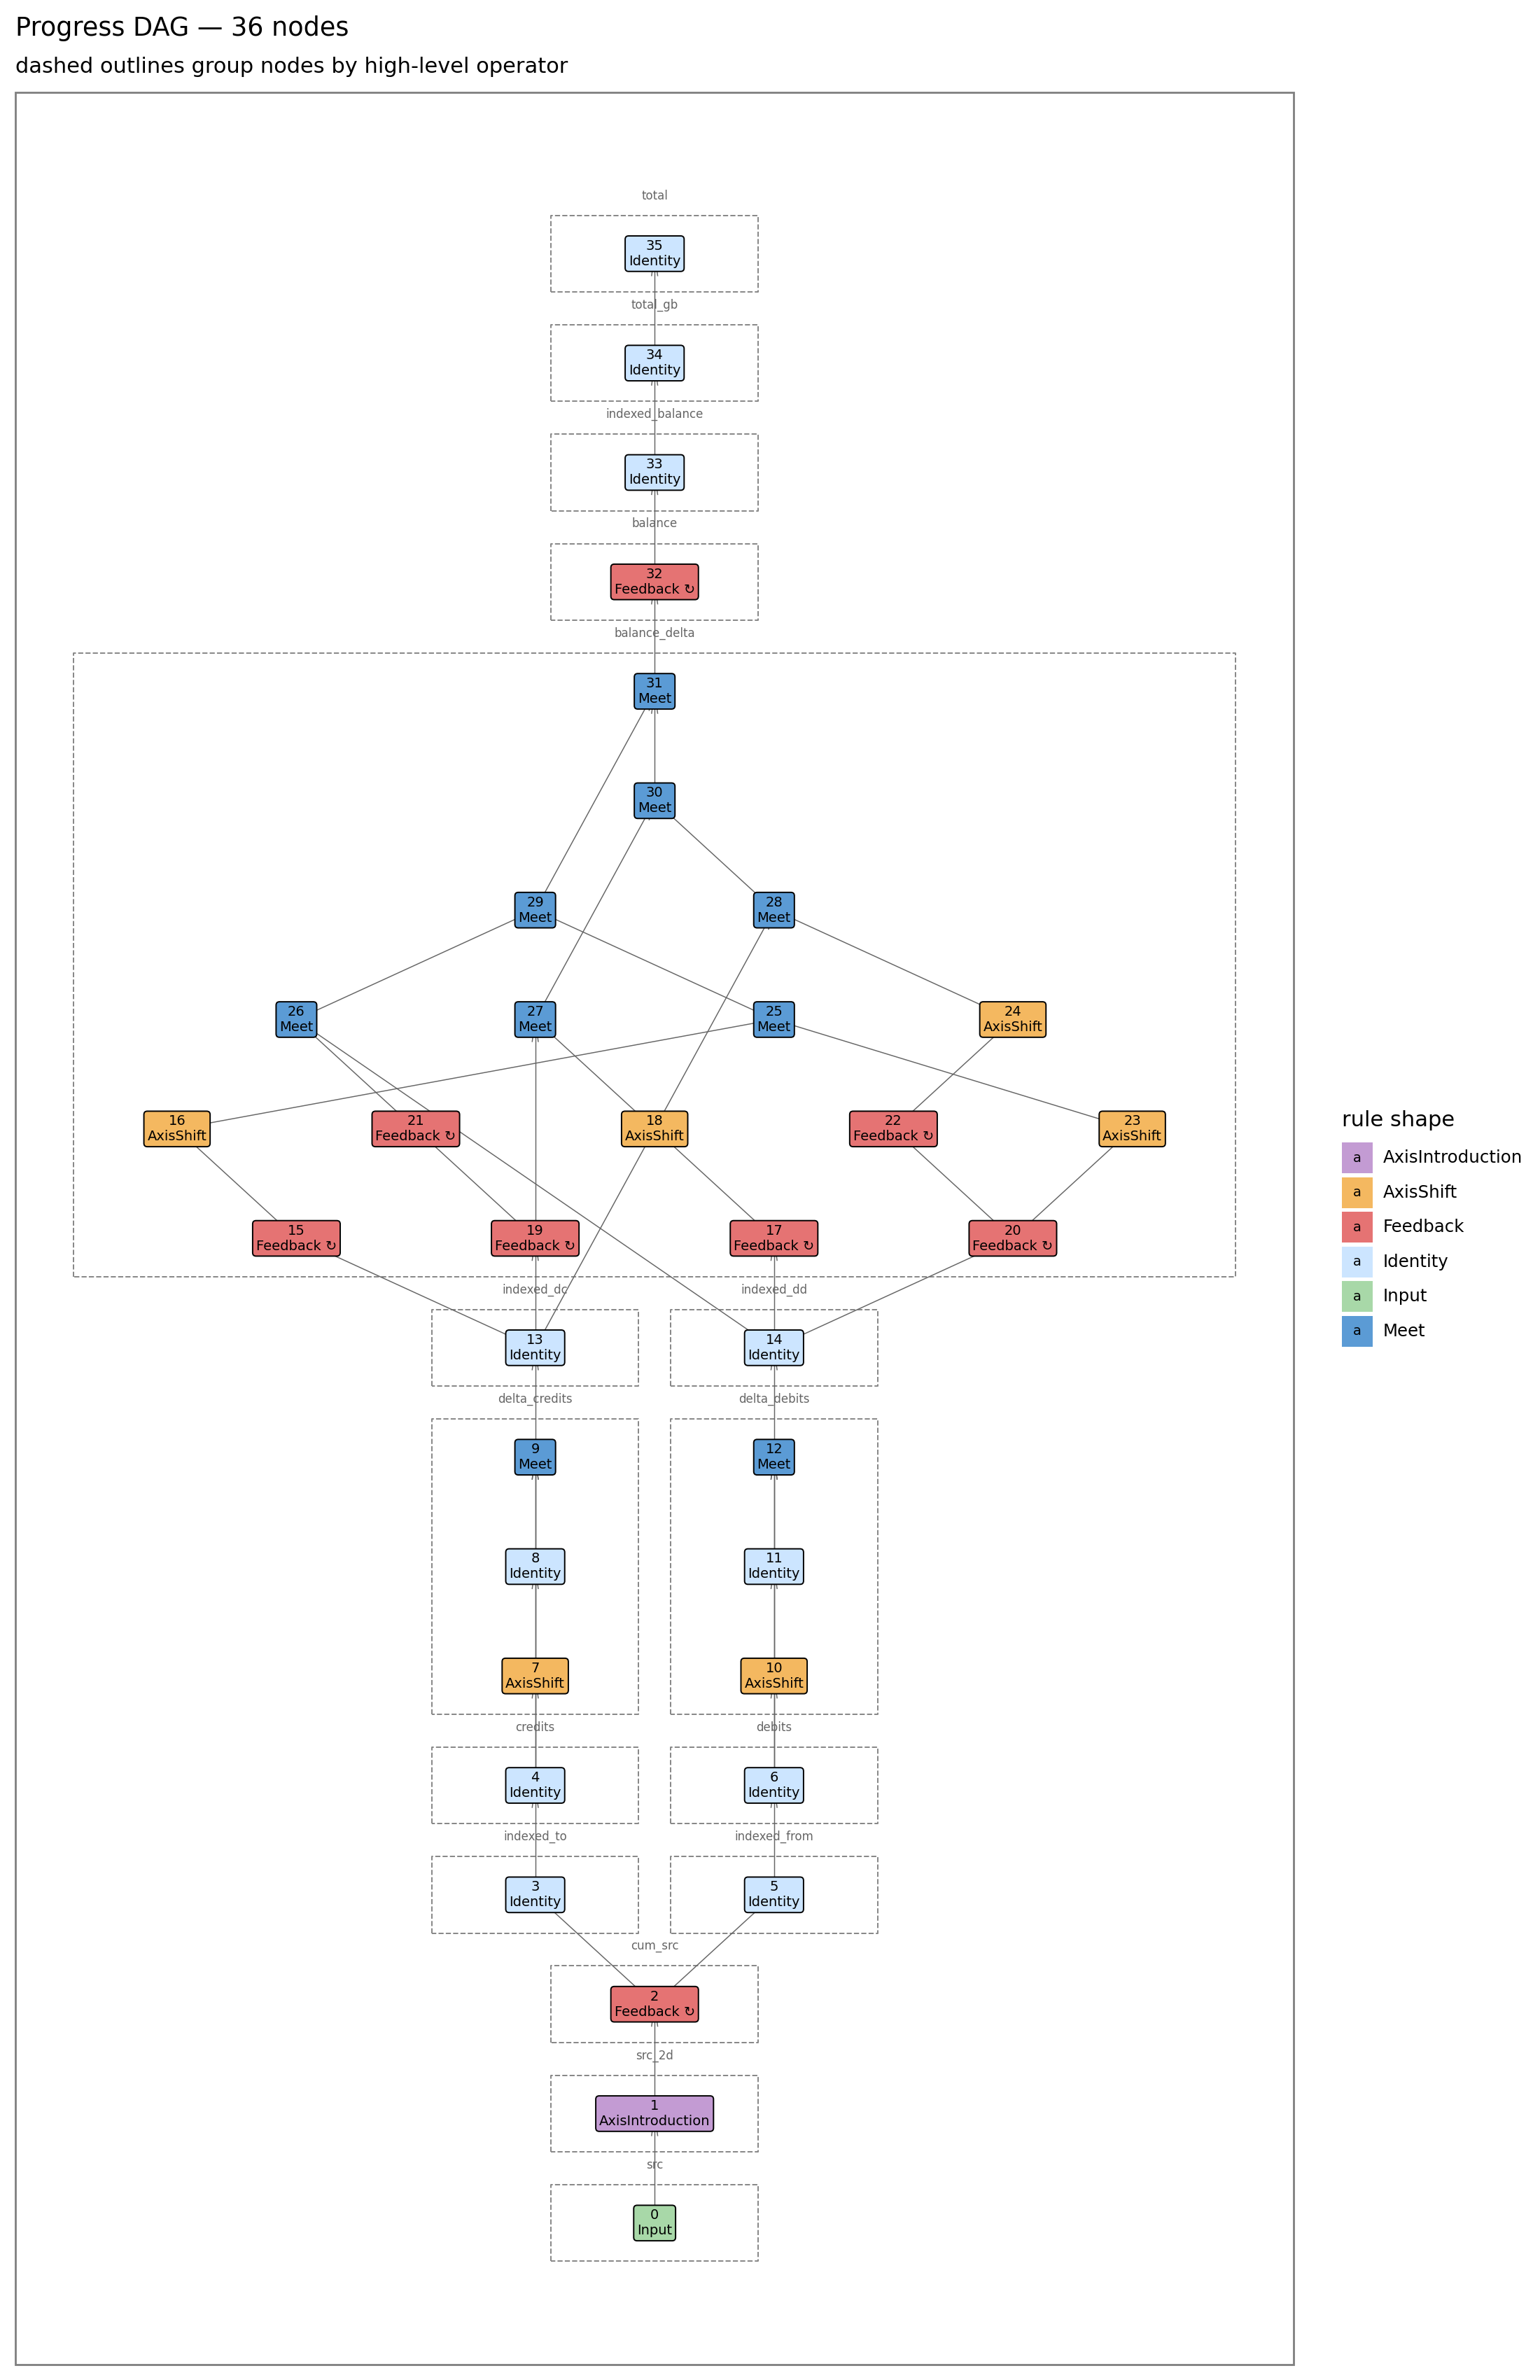

In [3]:
# Compute DAG + Progress DAG — same 36-node graph rendered twice, once
# coloured by ``algebra.compute`` rule shape and once by ``algebra.progress``
# rule shape. Dashed outlines group nodes by the high-level operator
# they belong to.

from IPython.display import display

# Bounding rectangles per operator over the shared node layout.
_rects: list[dict[str, float]] = []
_outline_labels: list[dict[str, float | str]] = []
for k in range(n_ops):
    lo, hi = op_lo[k], op_hi[k]
    xs = [x_of[j] for j in range(lo, hi + 1)]
    ys = [depths[j] for j in range(lo, hi + 1)]
    xmin, xmax = min(xs) - 0.65, max(xs) + 0.65
    ymin, ymax = min(ys) - 0.35, max(ys) + 0.35
    _rects.append({"xmin": xmin, "xmax": xmax, "ymin": ymin, "ymax": ymax})
    _outline_labels.append({
        "x": (xmin + xmax) / 2,
        "y": ymax + 0.18,
        "name": op_names[k].split("\n")[0],
    })
rects_df = pd.DataFrame(_rects)
outline_labels_df = pd.DataFrame(_outline_labels)

edges_df = pd.DataFrame([
    {"x": x_of[b], "y": depths[b], "xend": x_of[i], "yend": depths[i]}
    for i, p in enumerate(rules) for b in p.inputs
])


def _node_dag(color_map: dict[str, str], shape_fn, title: str, subtitle: str):
    nodes_df = pd.DataFrame([
        {
            "id": i,
            "x": x_of[i], "y": depths[i],
            "shape": shape_fn(i),
            "label": (
                f"{i}\n{shape_fn(i)}"
                + (" ↻" if shape_fn(i) in {"Feedback", "Sum"} else "")
            ),
        }
        for i in range(n_nodes)
    ])
    return (
        ggplot()
        + geom_rect(
            data=rects_df,
            mapping=aes(xmin="xmin", xmax="xmax", ymin="ymin", ymax="ymax"),
            fill="none", color="#888888", size=0.4, linetype="dashed",
        )
        + geom_text(
            data=outline_labels_df, mapping=aes(x="x", y="y", label="name"),
            size=6, color="#666666",
        )
        + geom_segment(
            data=edges_df, mapping=aes(x="x", y="y", xend="xend", yend="yend"),
            arrow=arrow(angle=18, length=0.05), size=0.3, color="#666666",
        )
        + geom_label(
            data=nodes_df, mapping=aes(x="x", y="y", label="label", fill="shape"),
            size=7,
        )
        + scale_fill_manual(values=color_map)
        + theme_bw()
        + theme(
            panel_grid_major=element_blank(),
            panel_grid_minor=element_blank(),
            axis_text=element_blank(),
            axis_ticks=element_blank(),
            axis_title=element_blank(),
            figure_size=(11, 17),
        )
        + labs(title=title, subtitle=subtitle, fill="rule shape")
    )


display(_node_dag(
    COMPUTE_COLOR,
    lambda i: type(c.compute_rules[i]).__name__,
    f"Compute DAG — {n_nodes} nodes",
    "dashed outlines group nodes by high-level operator",
))
display(_node_dag(
    PROGRESS_COLOR,
    lambda i: type(c.progress_rules[i]).__name__,
    f"Progress DAG — {n_nodes} nodes",
    "dashed outlines group nodes by high-level operator",
))

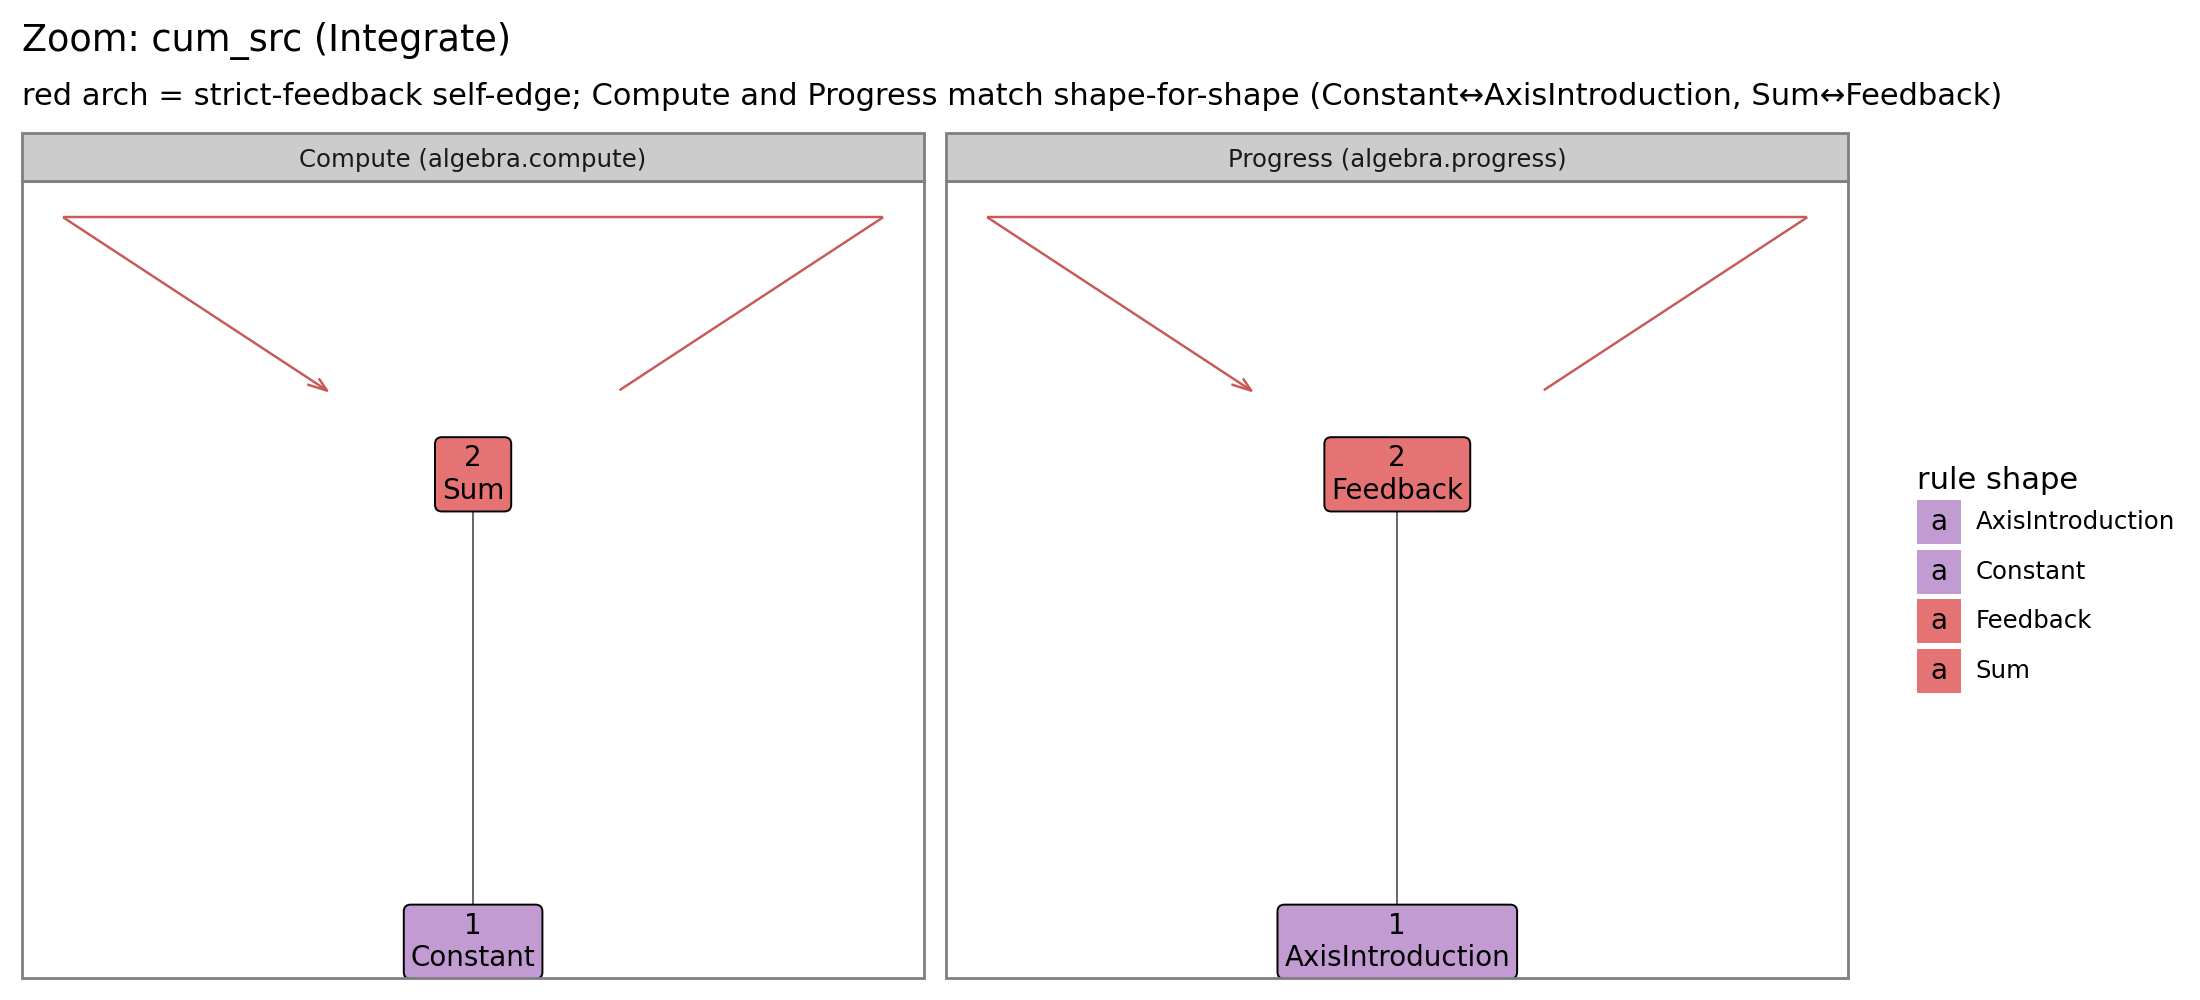

In [4]:
# Zoom: cum_src (Integrate) — Compute and Progress side-by-side.
#
# This pair of panels shows the duality between the value algebra
# (Constant / Sum) and the frontier algebra (AxisIntroduction / Feedback)
# at the smallest non-trivial subgraph: src_2d → cum_src, with the
# strict-feedback self-edge on cum_src drawn explicitly (the ↻ we
# abbreviate on the full DAGs).

PANELS = ("Compute (algebra.compute)", "Progress (algebra.progress)")
ZOOM_NODES = (src_2d, cum_src)   # node ids 1 and 2

zoom_df = pd.DataFrame([
    {
        "x": x_of[n], "y": depths[n],
        "label": f"{n}\n{type(c.compute_rules[n]).__name__}",
        "shape": type(c.compute_rules[n]).__name__,
        "panel": PANELS[0],
    }
    for n in ZOOM_NODES
] + [
    {
        "x": x_of[n], "y": depths[n],
        "label": f"{n}\n{type(c.progress_rules[n]).__name__}",
        "shape": type(c.progress_rules[n]).__name__,
        "panel": PANELS[1],
    }
    for n in ZOOM_NODES
])

# Forward edge src_2d → cum_src in each panel.
fwd_edges_df = pd.DataFrame([
    {
        "x": x_of[src_2d], "y": depths[src_2d],
        "xend": x_of[cum_src], "yend": depths[cum_src],
        "panel": pn,
    }
    for pn in PANELS
])

# Self-loop on cum_src — a 3-segment arch above the node. Last segment
# carries the arrowhead pointing back into the node.
_sx, _sy = x_of[cum_src], depths[cum_src]
self_no_arrow = pd.DataFrame([
    {"x": _sx + 0.25, "y": _sy + 0.18, "xend": _sx + 0.7, "yend": _sy + 0.55, "panel": pn}
    for pn in PANELS
] + [
    {"x": _sx + 0.7, "y": _sy + 0.55, "xend": _sx - 0.7, "yend": _sy + 0.55, "panel": pn}
    for pn in PANELS
])
self_with_arrow = pd.DataFrame([
    {"x": _sx - 0.7, "y": _sy + 0.55, "xend": _sx - 0.25, "yend": _sy + 0.18, "panel": pn}
    for pn in PANELS
])

ZOOM_FILL = {**COMPUTE_COLOR, **PROGRESS_COLOR}

(
    ggplot()
    + geom_segment(
        data=fwd_edges_df,
        mapping=aes(x="x", y="y", xend="xend", yend="yend"),
        arrow=arrow(angle=18, length=0.07), size=0.4, color="#666666",
    )
    + geom_segment(
        data=self_no_arrow,
        mapping=aes(x="x", y="y", xend="xend", yend="yend"),
        size=0.5, color="#c95a5a",
    )
    + geom_segment(
        data=self_with_arrow,
        mapping=aes(x="x", y="y", xend="xend", yend="yend"),
        arrow=arrow(angle=20, length=0.08), size=0.5, color="#c95a5a",
    )
    + geom_label(
        data=zoom_df,
        mapping=aes(x="x", y="y", label="label", fill="shape"),
        size=10,
    )
    + scale_fill_manual(values=ZOOM_FILL)
    + facet_wrap("~panel", ncol=2)
    + theme_bw()
    + theme(
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
        axis_title=element_blank(),
        figure_size=(11, 5),
    )
    + labs(
        title="Zoom: cum_src (Integrate)",
        subtitle="red arch = strict-feedback self-edge; Compute and Progress "
                 "match shape-for-shape (Constant↔AxisIntroduction, Sum↔Feedback)",
        fill="rule shape",
    )
)

In [5]:
# Drive the pipeline with real data — 5 ticks of small transaction
# batches — and print the antichain (frontier) at watch-nodes after
# each push, plus the value at the root.
#
# Notice how the 1-D ``src`` frontier ``{(t,)}`` becomes the 2-D
# frontier ``{(t, ω)}`` downstream of ``src_2d`` — that ω is the
# witness ``LiftStreamIntroduction.forward`` plants on the new axis
# ("settled at every inner tick on this outer"). The whole inner axis
# is universally observed in one go.

import random
from pydbsp.compute import ComputeCtx
from pydbsp.evaluate import Evaluator
from pydbsp.storage import DictStorage

e = Evaluator[Time](
    circuit=c,
    storage=DictStorage(),
    ctx=ComputeCtx(lattice=dbsp_time(2)),
    group=eg_record,
)

N_ACCOUNTS = 5
ROWS_PER_TICK = 3
N_TICKS = 5
rng = random.Random(0)

WATCH: list[tuple[str, int]] = [
    ("src",        src),
    ("src_2d",     src_2d),
    ("cum_src",    cum_src),
    ("credits",    credits),
    ("delta_cred", delta_credits),
    ("balance",    balance),
    ("total",      total),
]


def _fmt_antichain(a) -> str:
    if a.is_universal:
        return "⊤"
    if not a.elements:
        return "⊥"
    return "{" + ", ".join(str(elem) for elem in a.elements) + "}"


for tick in range(N_TICKS):
    batch_records = [
        (tick * ROWS_PER_TICK + i,
         rng.randrange(N_ACCOUNTS),
         rng.randrange(N_ACCOUNTS),
         1)
        for i in range(ROWS_PER_TICK)
    ]
    batch = ZSet({r: 1 for r in batch_records})
    e.push(src, batch)
    _ = e.read(total, (tick, 0))  # materialise the root at this tick

    print(f"=== tick {tick} ===")
    print(f"  pushed {ROWS_PER_TICK} txns (id, from, to, amount):")
    for rec in batch_records:
        print(f"    {rec}")

    frontiers = e.frontiers()
    print("  frontiers:")
    for label, nid in WATCH:
        print(f"    {label:11s} (node {nid:2d}): {_fmt_antichain(frontiers[nid])}")

    print(f"  total at (outer={tick}, inner=0) = {e.read(total, (tick, 0))}")
    print()

=== tick 0 ===
  pushed 3 txns (id, from, to, amount):
    (0, 3, 3, 1)
    (1, 0, 2, 1)
    (2, 4, 3, 1)
  frontiers:
    src         (node  0): {(0,)}
    src_2d      (node  1): {(0, inf)}
    cum_src     (node  2): {(0, inf)}
    credits     (node  4): {(0, inf)}
    delta_cred  (node  9): {(0, inf)}
    balance     (node 32): {(0, inf)}
    total       (node 35): {(0, inf)}
  total at (outer=0, inner=0) = 1

=== tick 1 ===
  pushed 3 txns (id, from, to, amount):
    (3, 3, 2, 1)
    (4, 3, 2, 1)
    (5, 4, 1, 1)
  frontiers:
    src         (node  0): {(1,)}
    src_2d      (node  1): {(1, inf)}
    cum_src     (node  2): {(1, inf)}
    credits     (node  4): {(1, inf)}
    delta_cred  (node  9): {(1, inf)}
    balance     (node 32): {(1, inf)}
    total       (node 35): {(1, inf)}
  total at (outer=1, inner=0) = -1

=== tick 2 ===
  pushed 3 txns (id, from, to, amount):
    (6, 4, 1, 1)
    (7, 2, 1, 1)
    (8, 0, 4, 1)
  frontiers:
    src         (node  0): {(2,)}
    src_2d    

cum_src storage after each tick (slots / total records):
  tick                   no GC                 with GC
     0    1 slot(s), 3 records    1 slot(s), 3 records
     1    2 slot(s), 9 records    2 slot(s), 9 records
     2   3 slot(s), 18 records   3 slot(s), 18 records
     3   4 slot(s), 30 records   3 slot(s), 27 records
     4   5 slot(s), 45 records   3 slot(s), 36 records


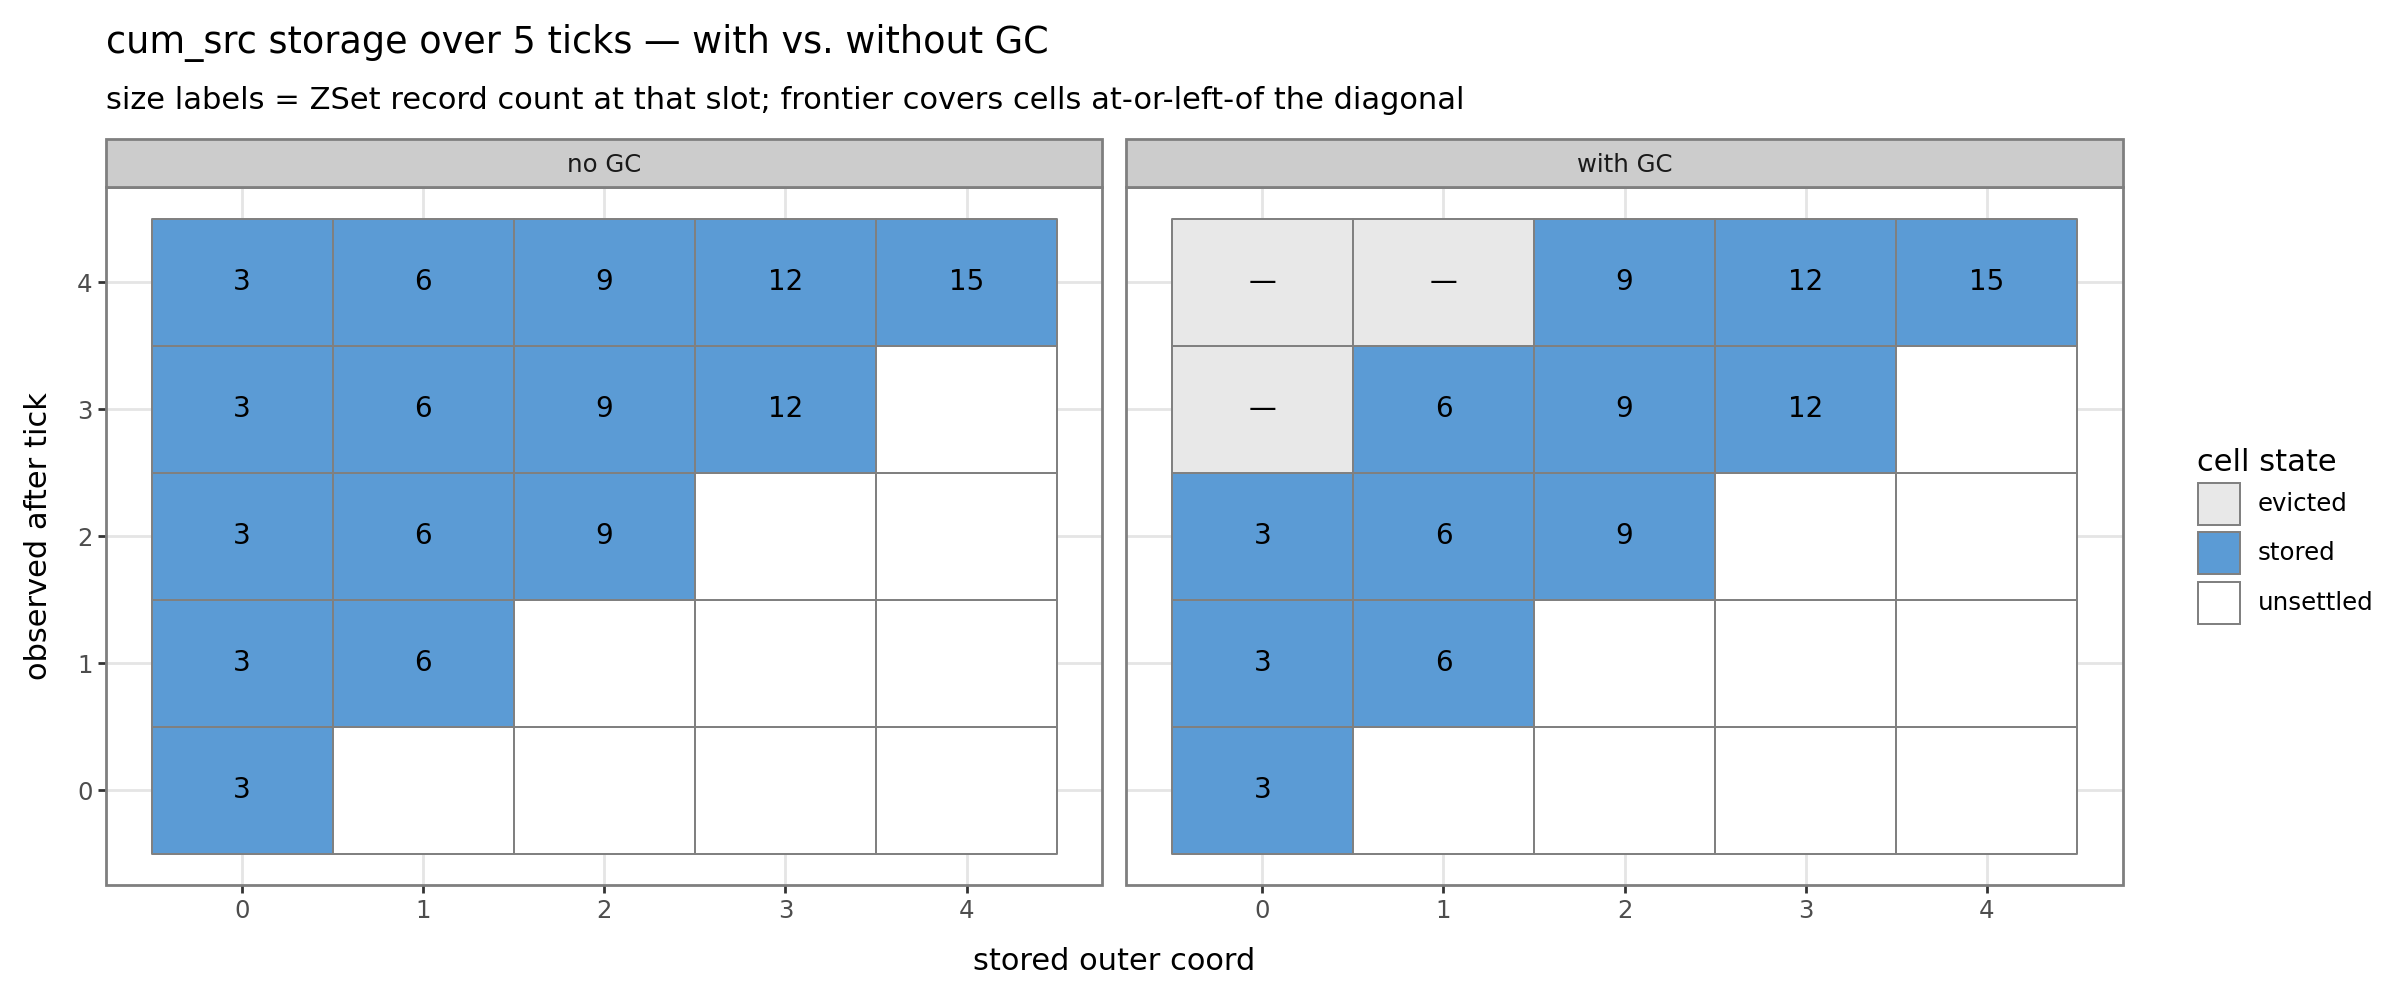

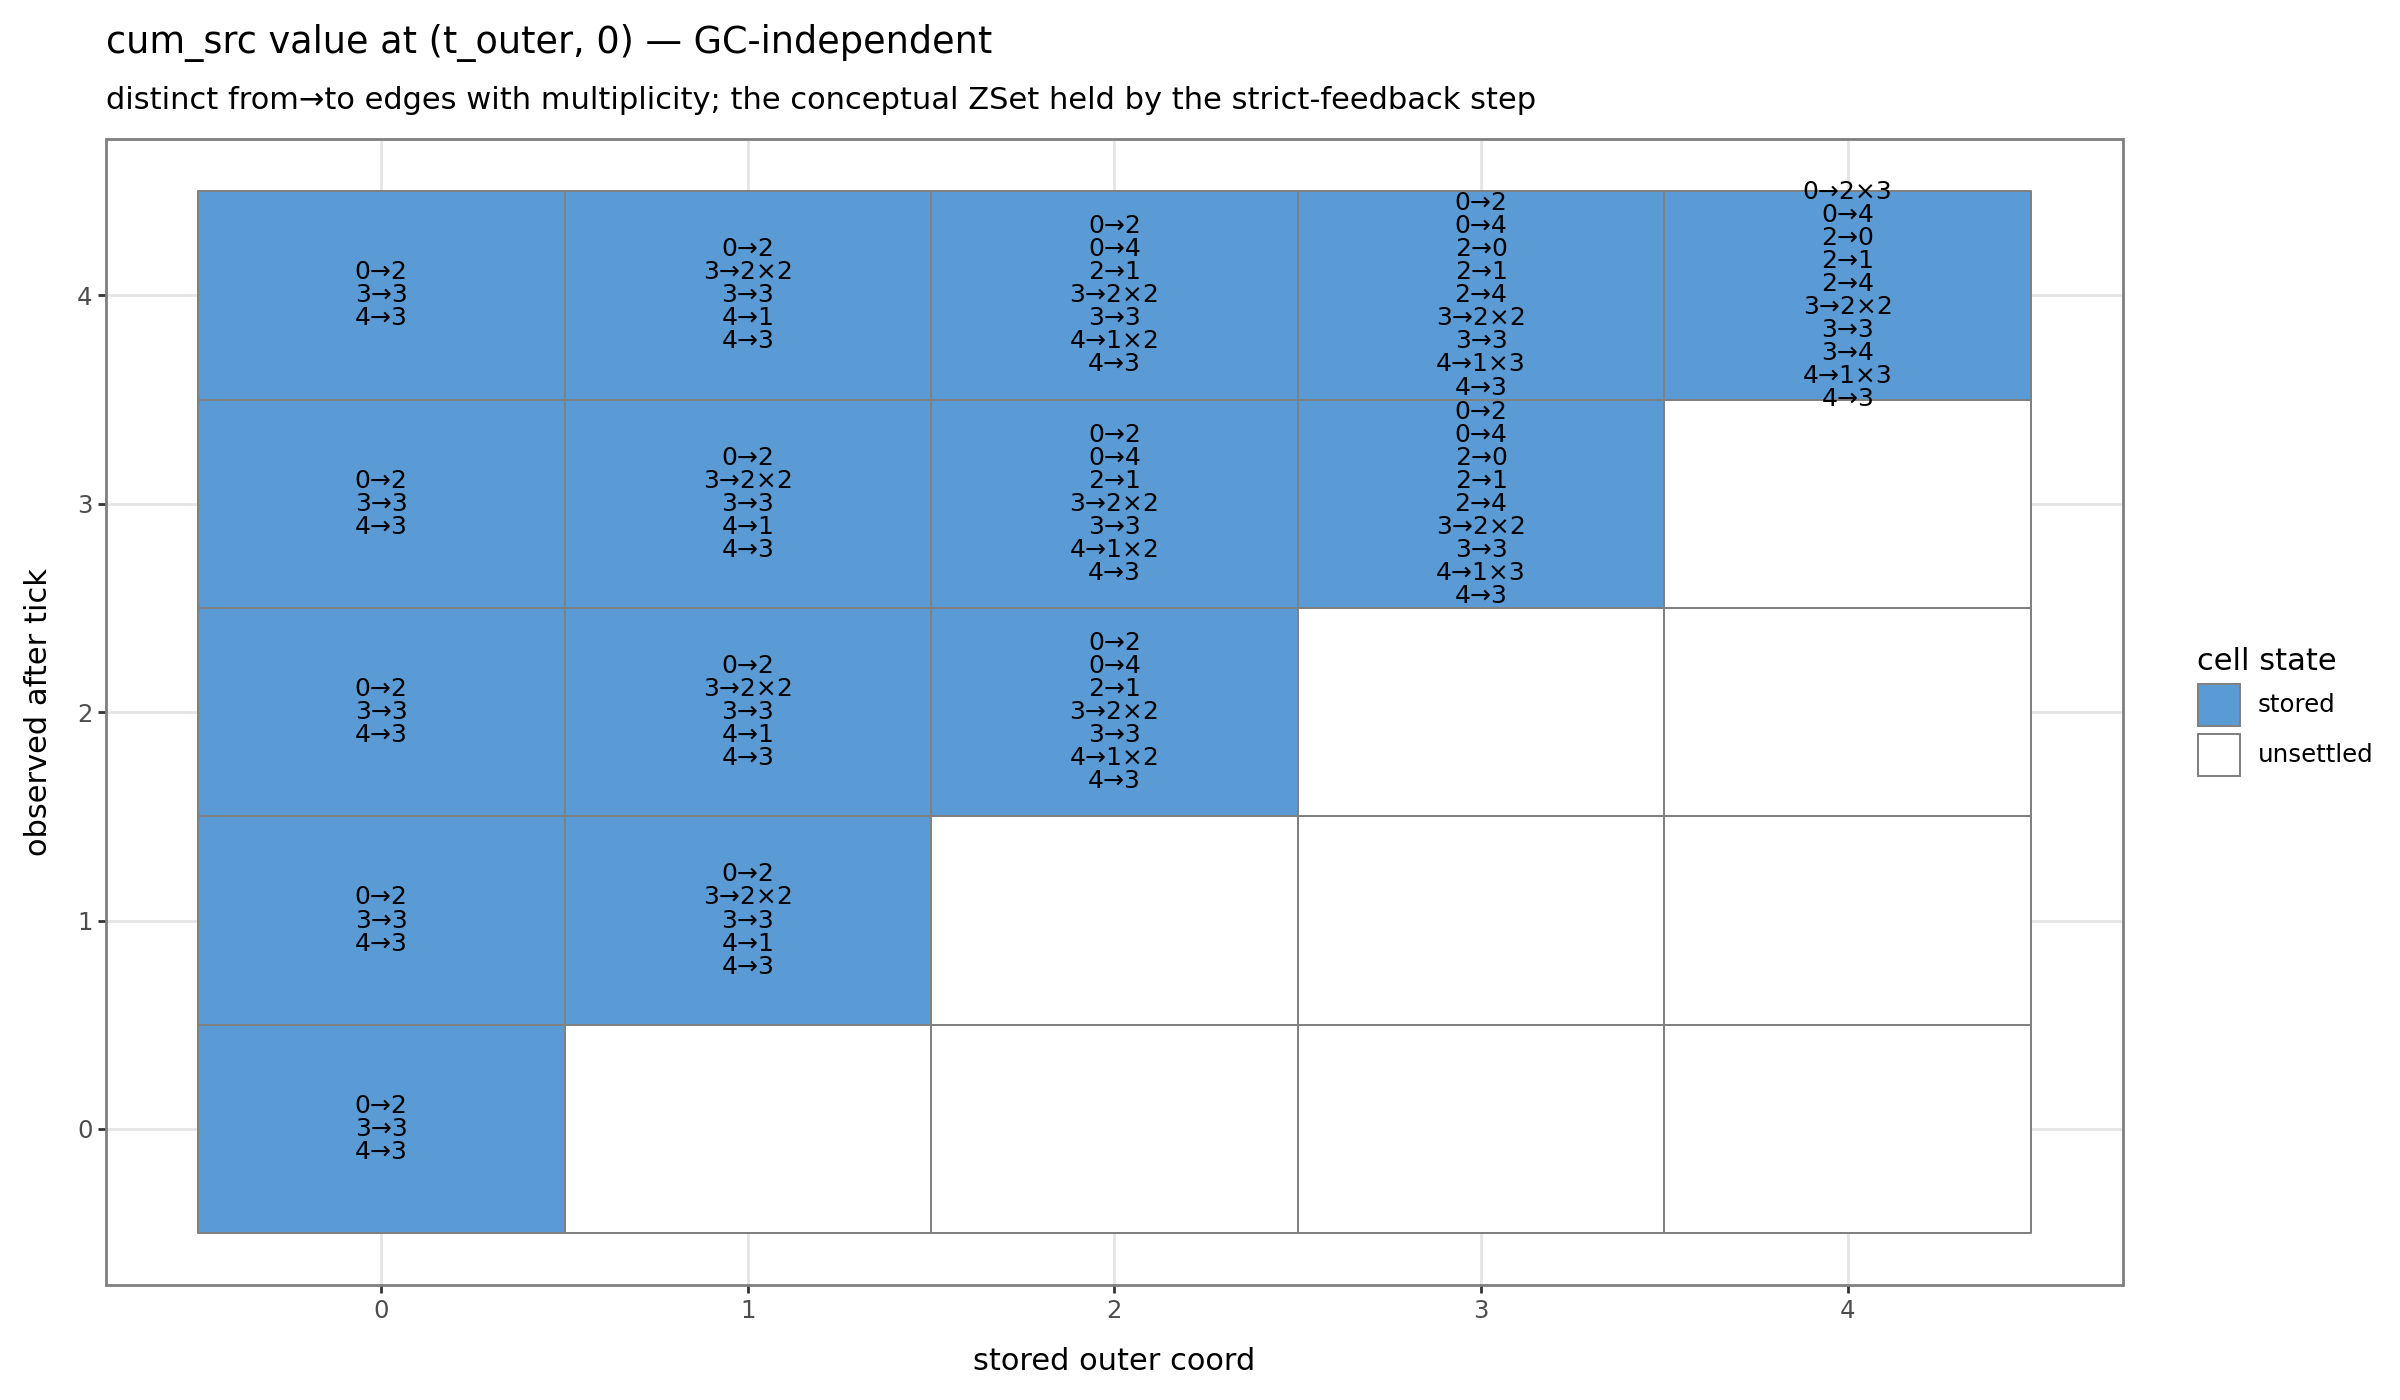

In [6]:
# cum_src storage state over 5 ticks — two stacked figures forming a
# 2-over-1 "triangle":
#
#   * **top**    — no GC / with GC, storage state with ZSet size labels.
#   * **bottom** — the conceptual ZSet held at ``cum_src(t_outer, 0)``,
#                  independent of GC. Same total width as the top, so its
#                  tiles are roughly twice as large — room for the
#                  multi-line ``from→to×n`` edge content.
#
# Cell encoding (both figures):
#   * **stored** (blue) — currently in storage *or* (bottom) the value at
#     that timestamp.
#   * **evicted** (grey, "—") — was stored, freed by ``e.compact()``.
#     Only appears in the with-GC panel.
#   * **unsettled** (white) — frontier hasn't advanced here yet.
#
# Without GC, the top-left panel's blue cells exactly match the bottom's
# content. With GC, the top-right panel drops the lower-left tail but the
# bottom still holds the same value — recoverable by recompute through
# ``Sum``'s strict-feedback chain, which is the soundness guarantee
# ``Evaluator.compact`` relies on.

import collections
import random
from pydbsp.compute import ComputeCtx
from pydbsp.evaluate import Evaluator
from pydbsp.progress import Input as PInput
from pydbsp.storage import DictStorage
from IPython.display import display
from plotnine import geom_tile


def _reset_src_input() -> None:
    """Replace src's progress rule with a fresh empty-frontier Input so
    the simulation can re-run from tick 0 regardless of prior cells'
    state. Only mutates the input's frontier; the rest of the circuit
    is untouched."""
    c.progress_rules[src] = PInput(frontier=Antichain(dbsp_time(1)))


def _run_and_snapshot(do_gc: bool) -> list[dict]:
    _reset_src_input()
    e_inst = Evaluator[Time](
        circuit=c, storage=DictStorage(),
        ctx=ComputeCtx(lattice=dbsp_time(2)), group=eg_record,
    )
    rng_l = random.Random(0)
    snaps: list[dict] = []
    for tick in range(N_TICKS):
        batch_records = [
            (tick * ROWS_PER_TICK + i,
             rng_l.randrange(N_ACCOUNTS),
             rng_l.randrange(N_ACCOUNTS), 1)
            for i in range(ROWS_PER_TICK)
        ]
        batch = ZSet({r: 1 for r in batch_records})
        e_inst.push(src, batch)
        _ = e_inst.read(total, (tick, 0))
        if do_gc:
            e_inst.compact()
        stored_times = e_inst.storage.times(cum_src)
        sizes = {
            t: sum(e_inst.storage.read(cum_src, t).inner.values())
            for t in stored_times
        }
        snaps.append({"tick": tick, "sizes": sizes})
    return snaps


snaps_nogc = _run_and_snapshot(False)
snaps_gc = _run_and_snapshot(True)
_reset_src_input()  # leave the global circuit in a clean state for re-runs


# Replay the same batches off-circuit to capture cum_src's value at
# each (t_outer, 0). The value is deterministic from the same seed —
# independent of whether the live evaluator GC'd.
def _format_value(records: list) -> str:
    counts = collections.Counter((r[1], r[2]) for r in records)
    return "\n".join(
        f"{f}→{to}" + (f"×{cnt}" if cnt > 1 else "")
        for (f, to), cnt in sorted(counts.items())
    )

_rng_v = random.Random(0)
_running: list = []
cum_value_str: dict[int, str] = {}
for _t in range(N_TICKS):
    _batch = [
        (_t * ROWS_PER_TICK + i,
         _rng_v.randrange(N_ACCOUNTS),
         _rng_v.randrange(N_ACCOUNTS), 1)
        for i in range(ROWS_PER_TICK)
    ]
    _running = _running + _batch
    cum_value_str[_t] = _format_value(_running)


# Long-form dataframes — top (storage) and bottom (value).
storage_rows: list[dict] = []
for mode, snaps in [("no GC", snaps_nogc), ("with GC", snaps_gc)]:
    for snap in snaps:
        tick = snap["tick"]
        for t_outer in range(N_TICKS):
            sz = snap["sizes"].get((t_outer, 0))
            settled = t_outer <= tick
            if sz is not None:
                state, label = "stored", str(sz)
            elif settled:
                state, label = "evicted", "—"
            else:
                state, label = "unsettled", ""
            storage_rows.append({
                "mode": mode, "tick": tick, "t_outer": t_outer,
                "state": state, "label": label,
            })
storage_df = pd.DataFrame(storage_rows)

value_rows: list[dict] = []
for tick in range(N_TICKS):
    for t_outer in range(N_TICKS):
        if t_outer <= tick:
            value_rows.append({
                "tick": tick, "t_outer": t_outer,
                "state": "stored", "label": cum_value_str[t_outer],
            })
        else:
            value_rows.append({
                "tick": tick, "t_outer": t_outer,
                "state": "unsettled", "label": "",
            })
value_df = pd.DataFrame(value_rows)


# Print the compact size table to anchor the plots.
print("cum_src storage after each tick (slots / total records):")
print(f"  {'tick':>4}  {'no GC':>22}  {'with GC':>22}")
for tick in range(N_TICKS):
    sz_no = snaps_nogc[tick]["sizes"]
    sz_gc = snaps_gc[tick]["sizes"]
    no_str = f"{len(sz_no)} slot(s), {sum(sz_no.values())} records"
    gc_str = f"{len(sz_gc)} slot(s), {sum(sz_gc.values())} records"
    print(f"  {tick:>4}  {no_str:>22}  {gc_str:>22}")

STATE_COLOR = {
    "unsettled": "#ffffff",
    "evicted":   "#e8e8e8",
    "stored":    "#5b9bd5",
}

storage_plot = (
    ggplot(storage_df, aes(x="t_outer", y="tick"))
    + geom_tile(aes(fill="state"), color="grey", size=0.4)
    + geom_text(aes(label="label"), size=10, color="black")
    + scale_fill_manual(values=STATE_COLOR, name="cell state")
    + facet_wrap("~mode", ncol=2)
    + theme_bw()
    + theme(
        panel_grid_minor=element_blank(),
        figure_size=(12, 5),
    )
    + labs(
        title=f"cum_src storage over {N_TICKS} ticks — with vs. without GC",
        subtitle=(
            "size labels = ZSet record count at that slot; "
            "frontier covers cells at-or-left-of the diagonal"
        ),
        x="stored outer coord", y="observed after tick",
    )
)

value_plot = (
    ggplot(value_df, aes(x="t_outer", y="tick"))
    + geom_tile(aes(fill="state"), color="grey", size=0.4)
    + geom_text(aes(label="label"), size=9, color="black", lineheight=0.95)
    + scale_fill_manual(values=STATE_COLOR, name="cell state")
    + theme_bw()
    + theme(
        panel_grid_minor=element_blank(),
        figure_size=(12, 7),
    )
    + labs(
        title="cum_src value at (t_outer, 0) — GC-independent",
        subtitle=(
            "distinct from→to edges with multiplicity; "
            "the conceptual ZSet held by the strict-feedback step"
        ),
        x="stored outer coord", y="observed after tick",
    )
)

display(storage_plot)
display(value_plot)

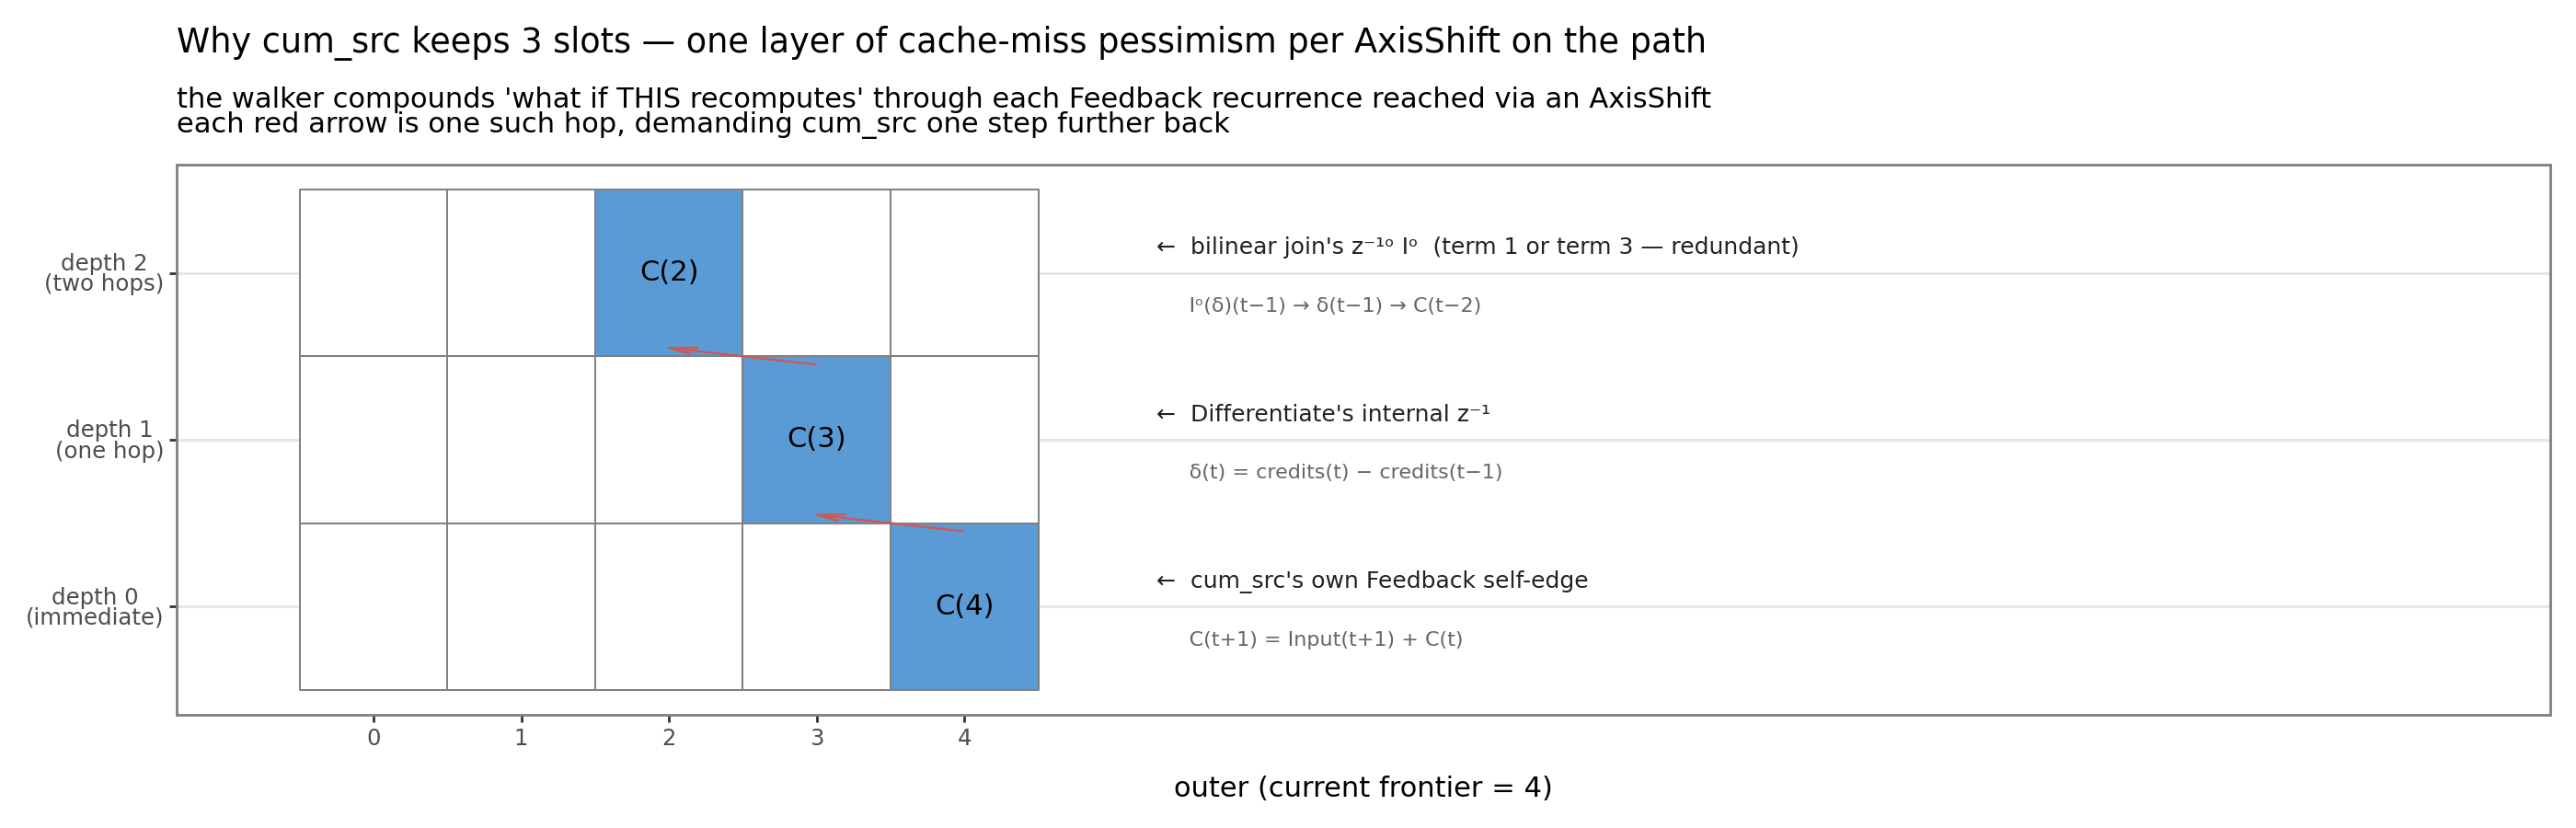

In [7]:
# Why does cum_src keep 3 slots — visualised as layered cache-miss
# pessimism.
#
# After tick ``t`` the GC walker prepares for the next read at ``t+1``.
# It does NOT know which downstream cells are memoised, so it treats
# every ``AxisShift`` on a cum_src-reaching path as "this might trigger
# a recompute, which would walk back through the Feedback's recurrence."
# Each such AxisShift compounds one more layer of "what if THIS too
# recomputed?" — and each layer demands cum_src one step further back.
#
# Three layers → three slots:
#
#   depth 0  cum_src self-edge:        C(t+1) = Input(t+1) + C(t)
#                                      → C(t)
#   depth 1  Differentiate's z⁻¹:       δ(t) = credits(t) − credits(t-1)
#                                      → if credits(t-1) recomputes
#                                      → C(t-1)
#   depth 2  bilinear join's z⁻¹ᵒ Iᵒ:  Iᵒ(δ)(t) reads Iᵒ(δ)(t-1) + δ(t).
#                                      → if Iᵒ(δ)(t-1) also recomputes:
#                                        δ(t-1) = credits(t-1) − credits(t-2)
#                                      → C(t-2)
#
# Each "if X recomputes" hop is one AxisShift in the structural walk.
# The walker is cache-pessimistic on every hop, regardless of whether
# the memo will actually hit.

N_TICKS_VIZ = N_TICKS
T = N_TICKS_VIZ - 1  # current frontier outer

layers = [
    (0, T,     "cum_src's own Feedback self-edge",
     "C(t+1) = Input(t+1) + C(t)"),
    (1, T - 1, "Differentiate's internal z⁻¹",
     "δ(t) = credits(t) − credits(t−1)"),
    (2, T - 2, "bilinear join's z⁻¹ᵒ Iᵒ  (term 1 or term 3 — redundant)",
     "Iᵒ(δ)(t−1) → δ(t−1) → C(t−2)"),
]

# Per-cell tiles: x = outer position, y = depth of cache-miss assumption.
tile_rows = []
for depth, demanded_outer, _, _ in layers:
    for outer in range(N_TICKS_VIZ):
        is_d = (outer == demanded_outer)
        tile_rows.append({
            "depth": depth,
            "outer": outer,
            "state": "demanded" if is_d else "open",
            "label": f"C({outer})" if is_d else "",
        })
why_tiles_df = pd.DataFrame(tile_rows)

# Red "→" arrows marking the descent from one layer to the next:
# "if THIS recomputed, we'd also need ONE more step back."
arrows_df = pd.DataFrame([
    {"x": T,     "y": 0.45, "xend": T - 1, "yend": 0.55},
    {"x": T - 1, "y": 1.45, "xend": T - 2, "yend": 1.55},
])

# Annotations to the right of each row: rule name + formula.
rule_df = pd.DataFrame([
    {"depth": d + 0.15, "outer": N_TICKS_VIZ + 0.3, "text": f"←  {rule}"}
    for d, _, rule, _ in layers
])
form_df = pd.DataFrame([
    {"depth": d - 0.20, "outer": N_TICKS_VIZ + 0.3, "text": f"     {formula}"}
    for d, _, _, formula in layers
])

from plotnine import scale_x_continuous, scale_y_continuous

(
    ggplot()
    + geom_tile(
        data=why_tiles_df,
        mapping=aes(x="outer", y="depth", fill="state"),
        color="grey", size=0.4,
    )
    + geom_text(
        data=why_tiles_df,
        mapping=aes(x="outer", y="depth", label="label"),
        size=11, color="black",
    )
    + geom_segment(
        data=arrows_df,
        mapping=aes(x="x", y="y", xend="xend", yend="yend"),
        arrow=arrow(angle=22, length=0.08), size=0.5, color="#c95a5a",
    )
    + geom_text(
        data=rule_df, mapping=aes(x="outer", y="depth", label="text"),
        ha="left", size=9, color="#222222",
    )
    + geom_text(
        data=form_df, mapping=aes(x="outer", y="depth", label="text"),
        ha="left", size=8, color="#666666",
    )
    + scale_fill_manual(
        values={"demanded": "#5b9bd5", "open": "#ffffff"}, guide=None,
    )
    + scale_x_continuous(
        breaks=list(range(N_TICKS_VIZ)),
        limits=(-0.6, N_TICKS_VIZ + 9),
    )
    + scale_y_continuous(
        breaks=[0, 1, 2],
        labels=["depth 0\n(immediate)", "depth 1\n(one hop)", "depth 2\n(two hops)"],
        limits=(-0.5, 2.5),
    )
    + theme_bw()
    + theme(
        panel_grid_minor=element_blank(),
        panel_grid_major_x=element_blank(),
        figure_size=(14, 4.5),
    )
    + labs(
        title="Why cum_src keeps 3 slots — one layer of cache-miss pessimism per AxisShift on the path",
        subtitle="the walker compounds 'what if THIS recomputes' through each Feedback recurrence reached via an AxisShift\n"
                 "each red arrow is one such hop, demanding cum_src one step further back",
        x=f"outer (current frontier = {T})", y="",
    )
)